In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

class RegressionPipeline:
    def __init__(self, random_state=42):
        self.random_state = random_state
        self.numeric_features = ['num_rooms', 'num_baths', 'square_meters', 'year_built', 
                               'num_supermarkets', 'num_crimes']
        self.categorical_features = ['orientation', 'door', 'neighborhood']
        self.boolean_features = ['is_furnished', 'has_pool', 'has_ac', 'accepts_pets']
        
    def prepare_preprocessing(self):
        # Numeric features pipeline
        numeric_transformer = Pipeline(steps=[
            ('imputer', KNNImputer(n_neighbors=5)),  # KNN imputer works better for MCAR
            ('scaler', StandardScaler())
        ])
        
        # Categorical features pipeline
        categorical_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(drop='first', sparse_output=False))
        ])
        
        # Boolean features pipeline
        boolean_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent'))
        ])
        
        # Combine all transformers
        self.preprocessor = ColumnTransformer(
            transformers=[
                ('num', numeric_transformer, self.numeric_features),
                ('cat', categorical_transformer, self.categorical_features),
                ('bool', boolean_transformer, self.boolean_features)
            ])
        
    def analyze_missing_values(self, X):
        """Analyze and visualize missing values patterns"""
        missing_summary = pd.DataFrame({
            'missing_count': X.isnull().sum(),
            'missing_percentage': (X.isnull().sum() / len(X) * 100).round(2)
        }).sort_values('missing_percentage', ascending=False)
        
        plt.figure(figsize=(10, 6))
        sns.barplot(x=missing_summary.index, y='missing_percentage', data=missing_summary)
        plt.xticks(rotation=45)
        plt.title('Missing Values Percentage by Feature')
        plt.tight_layout()
        plt.show()
        
        return missing_summary
    
    def analyze_relationships(self, X, y):
        """Analyze relationships between features and target"""
        # Correlation analysis for numeric features
        numeric_data = X[self.numeric_features].copy()
        numeric_data['target'] = y
        
        plt.figure(figsize=(12, 8))
        sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', center=0)
        plt.title('Correlation Matrix')
        plt.tight_layout()
        plt.show()
        
        # Box plots for categorical features
        for cat_feature in self.categorical_features:
            plt.figure(figsize=(10, 6))
            sns.boxplot(x=cat_feature, y='target', data=pd.concat([X, pd.Series(y, name='target')], axis=1))
            plt.xticks(rotation=45)
            plt.title(f'Target Distribution by {cat_feature}')
            plt.tight_layout()
            plt.show()
    
    def train_and_evaluate_models(self, X, y):
        """Train and evaluate multiple models"""
        # Prepare the data
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=self.random_state
        )
        
        # Define models to try
        models = {
            'Linear Regression': LinearRegression(),
            'Ridge Regression': Ridge(alpha=1.0),
            'Lasso Regression': Lasso(alpha=1.0),
            'Random Forest': RandomForestRegressor(n_estimators=100, random_state=self.random_state)
        }
        
        results = {}
        for name, model in models.items():
            # Create full pipeline
            pipeline = Pipeline([
                ('preprocessor', self.preprocessor),
                ('regressor', model)
            ])
            
            # Train and evaluate
            pipeline.fit(X_train, y_train)
            y_pred = pipeline.predict(X_test)
            
            # Calculate metrics
            results[name] = {
                'R2 Score': r2_score(y_test, y_pred),
                'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
                'CV Scores': cross_val_score(pipeline, X, y, cv=5, scoring='r2')
            }
            
            # Plot actual vs predicted
            plt.figure(figsize=(8, 6))
            plt.scatter(y_test, y_pred, alpha=0.5)
            plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
            plt.xlabel('Actual Values')
            plt.ylabel('Predicted Values')
            plt.title(f'{name}: Actual vs Predicted')
            plt.tight_layout()
            plt.show()
        
        return results
    
    def fit_predict(self, X, y, model_type='Ridge'):
        """Fit the best model and make predictions"""
        if model_type == 'Ridge':
            model = Ridge(alpha=1.0)
        elif model_type == 'Random Forest':
            model = RandomForestRegressor(n_estimators=100, random_state=self.random_state)
        else:
            raise ValueError("Unsupported model type")
        
        pipeline = Pipeline([
            ('preprocessor', self.preprocessor),
            ('regressor', model)
        ])
        
        pipeline.fit(X, y)
        return pipeline

In [3]:
def load_data(f_path: str) -> pd.DataFrame:
    """
    Load the dataset and split into features and target
    """
    data = pd.read_csv('data/train.csv', index_col="id")
    X = data.drop('price', axis=1)
    y = data['price']
    return X, y

In [8]:
X,y = load_data('data/train.csv')


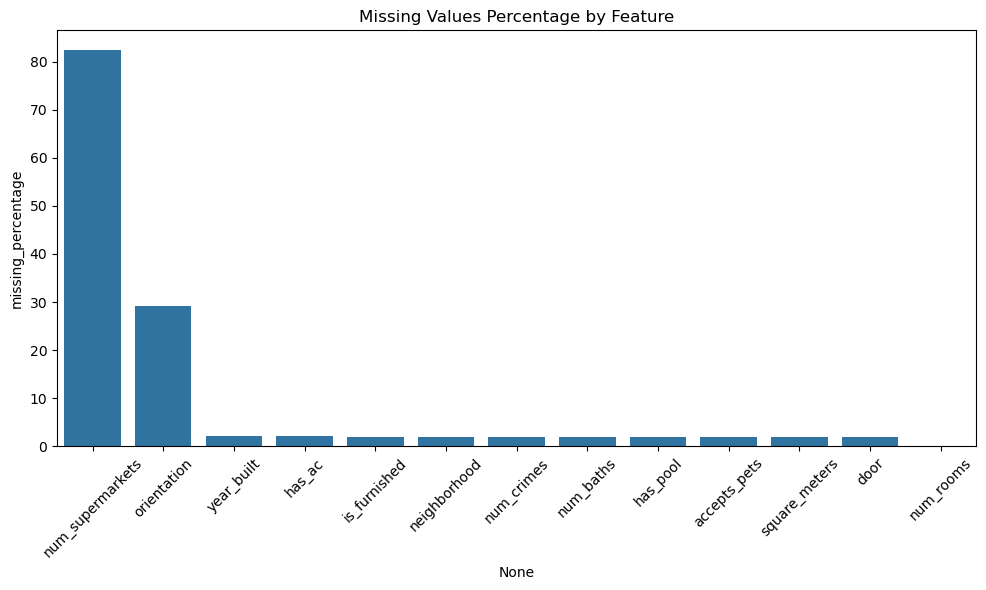

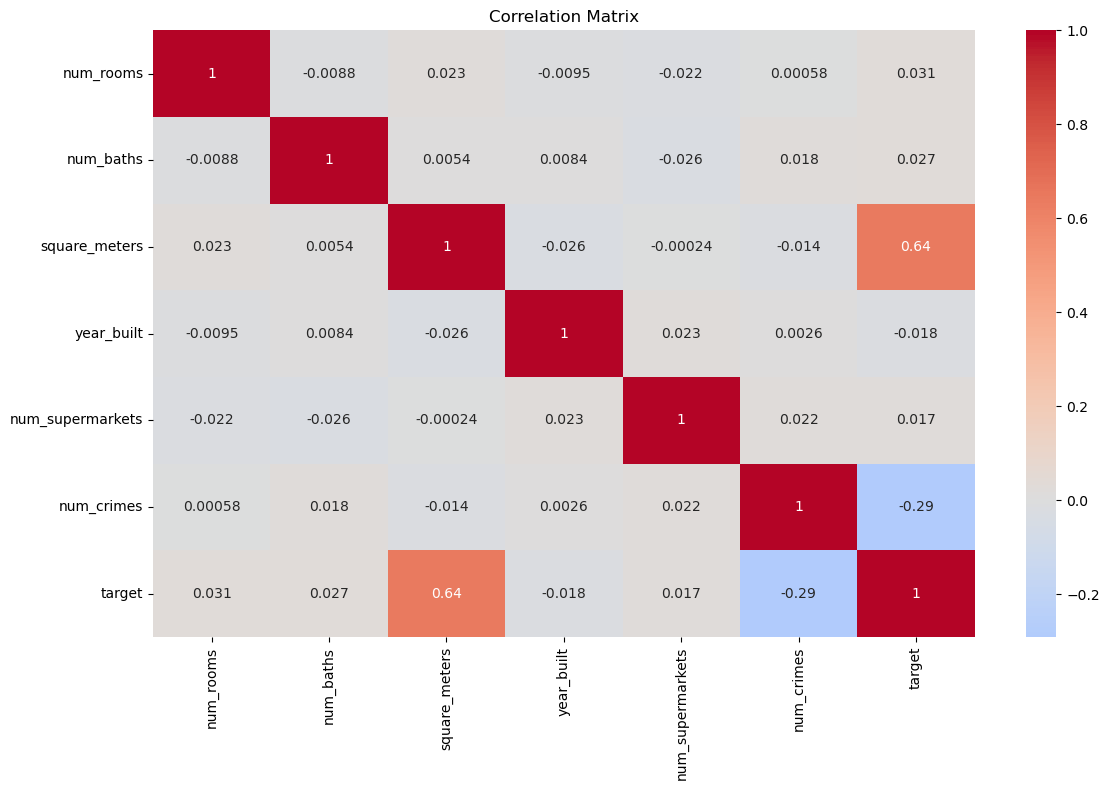

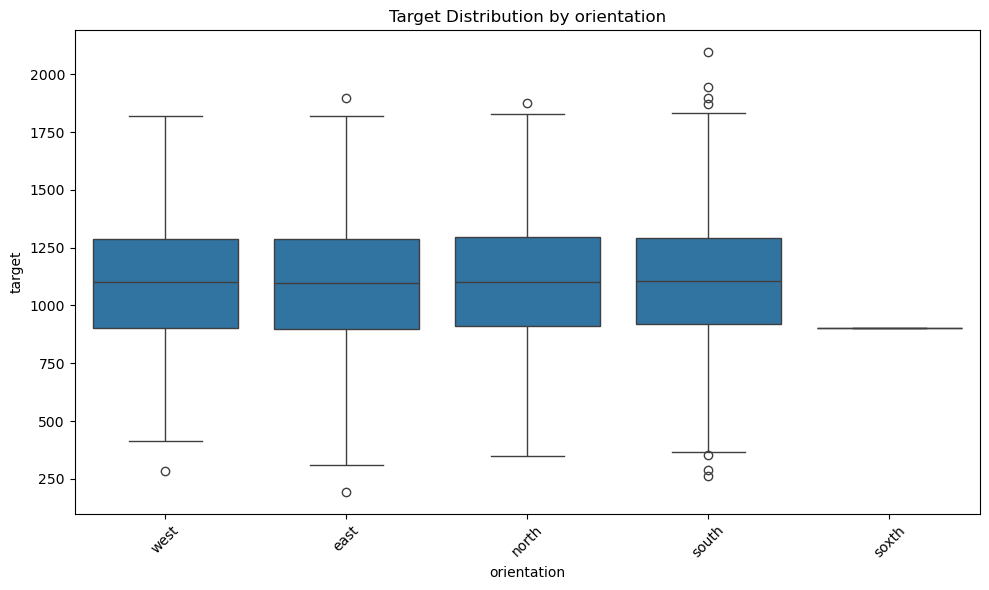

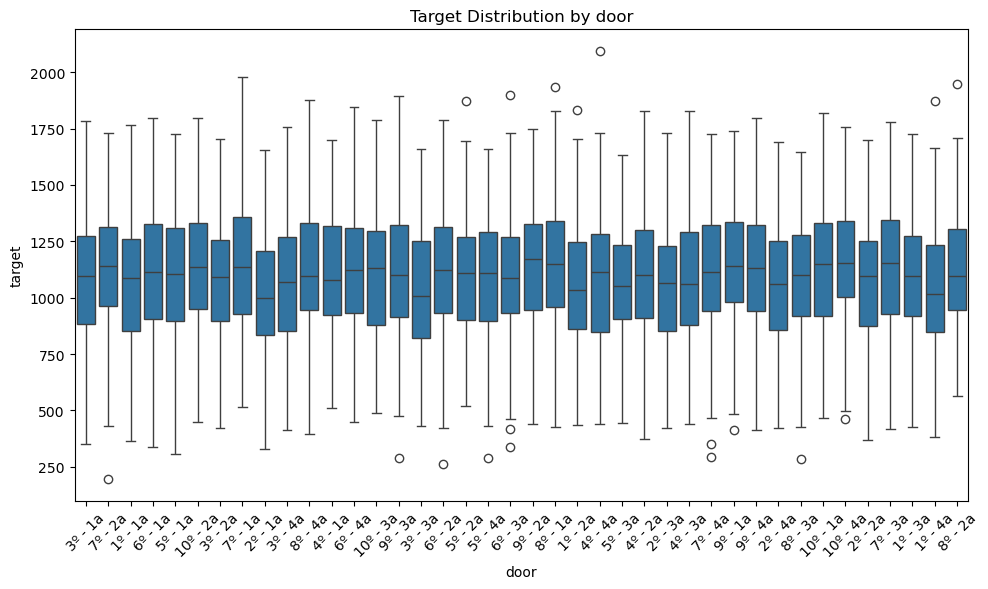

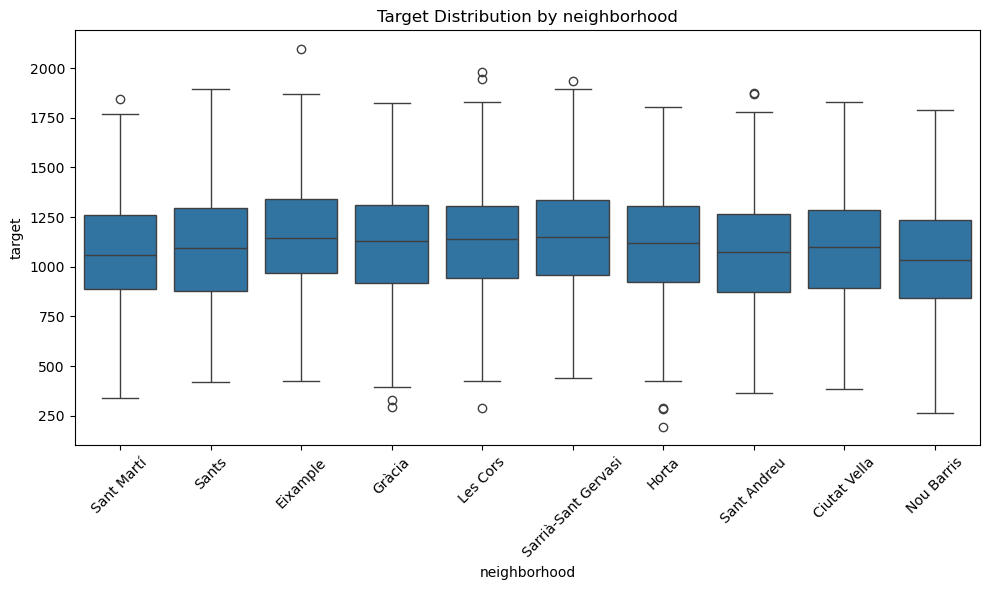

/home/m9o8/miniforge3/envs/std_linux/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:1000: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/m9o8/miniforge3/envs/std_linux/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 139, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/home/m9o8/miniforge3/envs/std_linux/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 371, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/home/m9o8/miniforge3/envs/std_linux/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 89, in _cached_call
    result, _ = _get_response_values(
                ^^^^^^^^^^^^^^^^^^^^^
  File "/home/m9o8/miniforge3/envs/std_linux/lib/python3.12/site-packages/sklearn/utils/_response.py", line 239, in _get_response_values
    y_pred, pos_label = prediction_m

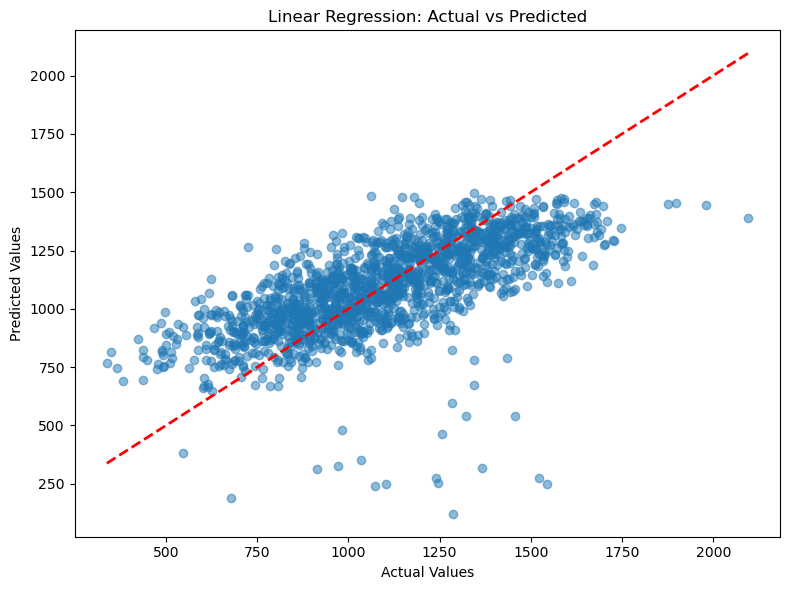

/home/m9o8/miniforge3/envs/std_linux/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:1000: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/m9o8/miniforge3/envs/std_linux/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 139, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/home/m9o8/miniforge3/envs/std_linux/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 371, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/home/m9o8/miniforge3/envs/std_linux/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 89, in _cached_call
    result, _ = _get_response_values(
                ^^^^^^^^^^^^^^^^^^^^^
  File "/home/m9o8/miniforge3/envs/std_linux/lib/python3.12/site-packages/sklearn/utils/_response.py", line 239, in _get_response_values
    y_pred, pos_label = prediction_m

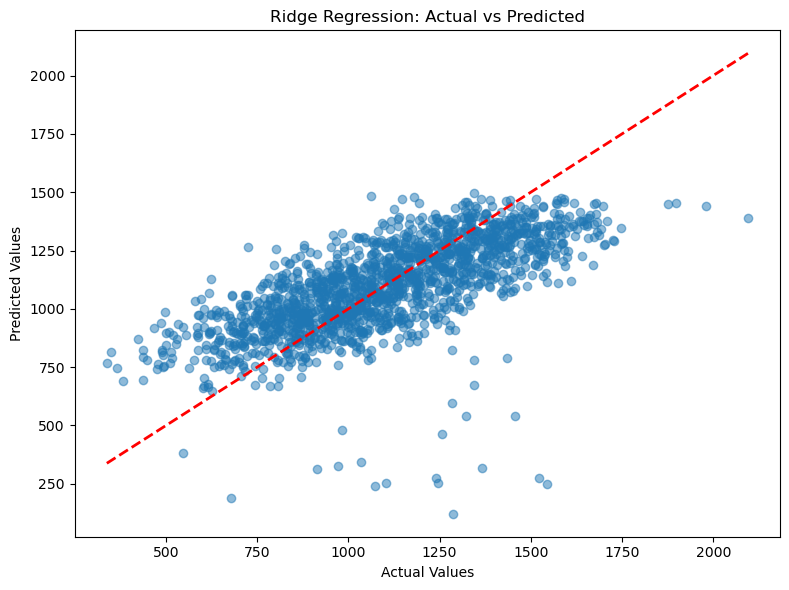

/home/m9o8/miniforge3/envs/std_linux/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:1000: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/m9o8/miniforge3/envs/std_linux/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 139, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/home/m9o8/miniforge3/envs/std_linux/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 371, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/home/m9o8/miniforge3/envs/std_linux/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 89, in _cached_call
    result, _ = _get_response_values(
                ^^^^^^^^^^^^^^^^^^^^^
  File "/home/m9o8/miniforge3/envs/std_linux/lib/python3.12/site-packages/sklearn/utils/_response.py", line 239, in _get_response_values
    y_pred, pos_label = prediction_m

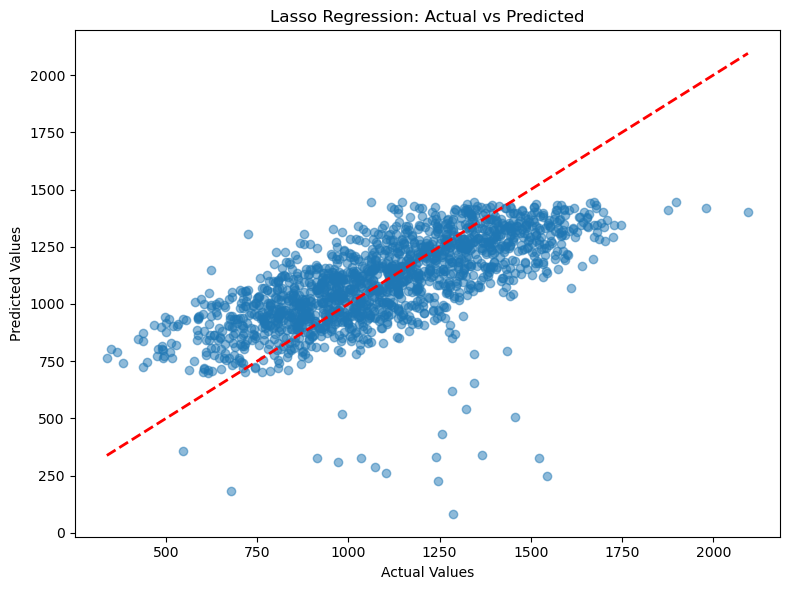

/home/m9o8/miniforge3/envs/std_linux/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:1000: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/m9o8/miniforge3/envs/std_linux/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 139, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/home/m9o8/miniforge3/envs/std_linux/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 371, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/home/m9o8/miniforge3/envs/std_linux/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 89, in _cached_call
    result, _ = _get_response_values(
                ^^^^^^^^^^^^^^^^^^^^^
  File "/home/m9o8/miniforge3/envs/std_linux/lib/python3.12/site-packages/sklearn/utils/_response.py", line 239, in _get_response_values
    y_pred, pos_label = prediction_m

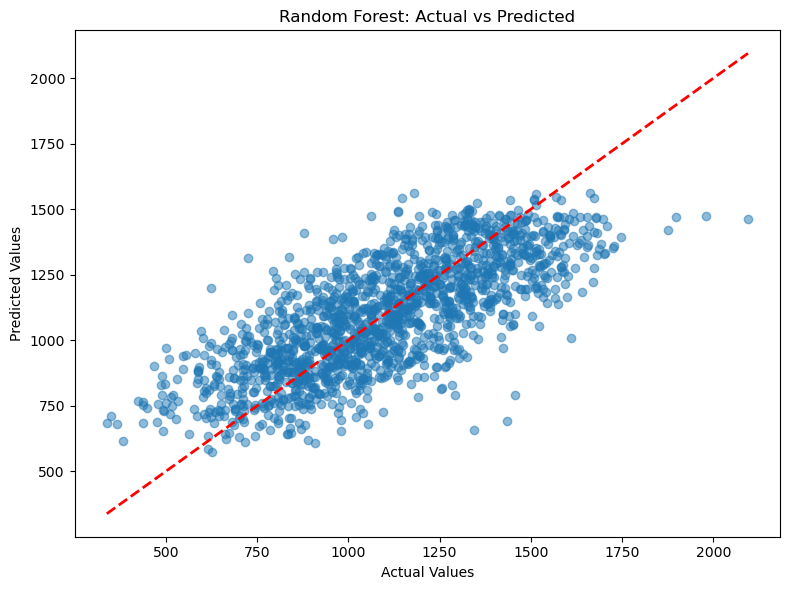


Linear Regression:
R2 Score: 0.4570
RMSE: 202.0010
CV Scores Mean: nan (+/- nan)

Ridge Regression:
R2 Score: 0.4568
RMSE: 202.0451
CV Scores Mean: nan (+/- nan)

Lasso Regression:
R2 Score: 0.4486
RMSE: 203.5651
CV Scores Mean: nan (+/- nan)

Random Forest:
R2 Score: 0.5489
RMSE: 184.1249
CV Scores Mean: nan (+/- nan)


In [9]:

# Initialize the pipeline
pipeline = RegressionPipeline()
pipeline.prepare_preprocessing()

# Analyze missing values and relationships
pipeline.analyze_missing_values(X)
pipeline.analyze_relationships(X, y)

# Train and evaluate models
results = pipeline.train_and_evaluate_models(X, y)

# Print results
for model_name, metrics in results.items():
    print(f"\n{model_name}:")
    print(f"R2 Score: {metrics['R2 Score']:.4f}")
    print(f"RMSE: {metrics['RMSE']:.4f}")
    print(f"CV Scores Mean: {metrics['CV Scores'].mean():.4f} (+/- {metrics['CV Scores'].std() * 2:.4f})")

# Fit final model and make predictions
final_model = pipeline.fit_predict(X, y, model_type='Ridge')
#predictions = final_model.predict(new_data)

In [10]:
X,y = load_data('data/test.csv')
predictions = final_model.predict(X)

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.covariance import EllipticEnvelope
import matplotlib.pyplot as plt
import seaborn as sns

class RegressionPipeline:
    def __init__(self, random_state=42):
        self.random_state = random_state
        self.numeric_features = ['num_rooms', 'num_baths', 'square_meters', 'year_built', 
                               'num_supermarkets', 'num_crimes']
        self.categorical_features = ['orientation', 'door', 'neighborhood']
        self.boolean_features = ['is_furnished', 'has_pool', 'has_ac', 'accepts_pets']
        
    def initial_imputation(self, X):
        """
        Perform initial imputation of missing values before outlier detection
        """
        # Create a copy of the data
        X_imputed = X.copy()
        
        # Initial imputation for numeric features
        numeric_imputer = SimpleImputer(strategy='median')
        X_imputed[self.numeric_features] = numeric_imputer.fit_transform(X[self.numeric_features])
        
        # Initial imputation for categorical features
        cat_imputer = SimpleImputer(strategy='most_frequent')
        X_imputed[self.categorical_features] = cat_imputer.fit_transform(X[self.categorical_features])
        
        # Initial imputation for boolean features
        bool_imputer = SimpleImputer(strategy='most_frequent')
        X_imputed[self.boolean_features] = bool_imputer.fit_transform(X[self.boolean_features])
        
        return X_imputed
        
    def detect_outliers(self, X, contamination=0.1, method='isolation_forest'):
        """
        Detect outliers in numeric features using multiple methods
        Returns a DataFrame with outlier flags and scores
        """
        # First, perform initial imputation
        X_imputed = self.initial_imputation(X)
        numeric_data = X_imputed[self.numeric_features].copy()
        
        # Initialize outlier detectors
        detectors = {
            'isolation_forest': IsolationForest(contamination=contamination, 
                                              random_state=self.random_state),
            'robust_covariance': EllipticEnvelope(contamination=contamination, 
                                                 random_state=self.random_state),
            'zscore': None,  # Will be handled separately
            'iqr': None      # Will be handled separately
        }
        
        results = pd.DataFrame(index=X.index)
        
        if method == 'isolation_forest' or method == 'all':
            # Isolation Forest detection
            iso_forest = detectors['isolation_forest']
            results['isolation_forest'] = iso_forest.fit_predict(numeric_data)
            
        if method == 'robust_covariance' or method == 'all':
            # Robust covariance detection
            try:
                robust_cov = detectors['robust_covariance']
                results['robust_covariance'] = robust_cov.fit_predict(numeric_data)
            except ValueError:
                print("Robust covariance failed - falling back to IQR method")
                method = 'iqr'
        
        if method == 'zscore' or method == 'all':
            # Z-score method
            z_scores = np.abs(StandardScaler().fit_transform(numeric_data))
            results['zscore'] = (z_scores.mean(axis=1) > 3).astype(int) * 2 - 1
            
        if method == 'iqr' or method == 'all':
            # IQR method
            Q1 = numeric_data.quantile(0.25)
            Q3 = numeric_data.quantile(0.75)
            IQR = Q3 - Q1
            outlier_mask = ((numeric_data < (Q1 - 1.5 * IQR)) | 
                          (numeric_data > (Q3 + 1.5 * IQR))).any(axis=1)
            results['iqr'] = outlier_mask.astype(int) * 2 - 1
        
        # Combine results if multiple methods are used
        if method == 'all':
            results['combined'] = results.mode(axis=1)[0]
        else:
            results['combined'] = results[method]
            
        return results, X_imputed
    
    def handle_outliers(self, X, method='isolation_forest'):
        """
        Detect and handle outliers by treating them as missing values
        """
        # Get outlier detection results and initially imputed data
        outlier_results, X_imputed = self.detect_outliers(X, method=method)
        
        # Create a copy of the original data
        X_cleaned = X.copy()
        
        # Mark outliers as NaN in numeric features
        for feature in self.numeric_features:
            # Keep original missing values as NaN
            original_missing = X[feature].isna()
            
            # Mark outliers as NaN, but only for non-missing values
            outlier_mask = (outlier_results['combined'] == -1) & ~original_missing
            X_cleaned.loc[outlier_mask, feature] = np.nan
            
        return X_cleaned
    
    def prepare_preprocessing(self):
        """
        Prepare the preprocessing pipeline with outlier handling
        """
        # Numeric features pipeline with KNN imputation for final values
        numeric_transformer = Pipeline(steps=[
            ('imputer', KNNImputer(n_neighbors=5)),  # KNN imputer for both missing values and outliers
            ('scaler', StandardScaler())
        ])
        
        # Categorical features pipeline
        categorical_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(drop='first', sparse_output=False))
        ])
        
        # Boolean features pipeline
        boolean_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent'))
        ])
        
        # Combine all transformers
        self.preprocessor = ColumnTransformer(
            transformers=[
                ('num', numeric_transformer, self.numeric_features),
                ('cat', categorical_transformer, self.categorical_features),
                ('bool', boolean_transformer, self.boolean_features)
            ])
    
    def analyze_data_quality(self, X, plot=True):
        """
        Comprehensive analysis of data quality including missing values and outliers
        """
        # First, get initially imputed data for outlier detection
        outlier_results, X_imputed = self.detect_outliers(X)
        
        results = pd.DataFrame(index=self.numeric_features)
        
        # Analyze each numeric feature
        for feature in self.numeric_features:
            original_data = X[feature]
            imputed_data = X_imputed[feature]
            
            # Basic statistics
            stats = {
                'missing_count': original_data.isnull().sum(),
                'missing_percentage': (original_data.isnull().sum() / len(original_data) * 100).round(2),
                'mean': imputed_data.mean(),
                'median': imputed_data.median(),
                'std': imputed_data.std(),
                'min': imputed_data.min(),
                'max': imputed_data.max()
            }
            
            # Count outliers (using IQR method as an example)
            Q1 = imputed_data.quantile(0.25)
            Q3 = imputed_data.quantile(0.75)
            IQR = Q3 - Q1
            outlier_count = ((imputed_data < (Q1 - 1.5 * IQR)) | 
                           (imputed_data > (Q3 + 1.5 * IQR))).sum()
            stats['outlier_count'] = outlier_count
            stats['outlier_percentage'] = (outlier_count / len(imputed_data) * 100).round(2)
            
            results[feature] = pd.Series(stats)
        
        if plot:
            # Plot distribution with outliers highlighted
            for feature in self.numeric_features:
                plt.figure(figsize=(10, 6))
                
                # Create box plot
                plt.subplot(2, 1, 1)
                sns.boxplot(x=X_imputed[feature])
                plt.title(f'{feature} Distribution and Outliers')
                
                # Create histogram
                plt.subplot(2, 1, 2)
                sns.histplot(data=X_imputed, x=feature, kde=True)
                plt.title(f'{feature} Distribution')
                
                plt.tight_layout()
                plt.show()
        
        return results.T
    
    def analyze_relationships(self, X, y):
        """Analyze relationships between features and target"""
        # First handle outliers
        X_cleaned = self.handle_outliers(X)
        
        # Initial imputation for correlation analysis
        X_imputed = self.initial_imputation(X_cleaned)
        
        # Correlation analysis for numeric features
        numeric_data = X_imputed[self.numeric_features].copy()
        numeric_data['target'] = y
        
        plt.figure(figsize=(12, 8))
        sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', center=0)
        plt.title('Correlation Matrix (After Outlier Handling)')
        plt.tight_layout()
        plt.show()
        
        # Box plots for categorical features
        for cat_feature in self.categorical_features:
            plt.figure(figsize=(10, 6))
            sns.boxplot(x=cat_feature, y='target', 
                       data=pd.concat([X_imputed, pd.Series(y, name='target')], axis=1))
            plt.xticks(rotation=45)
            plt.title(f'Target Distribution by {cat_feature}')
            plt.tight_layout()
            plt.show()
    
    def train_and_evaluate_models(self, X, y):
        """Train and evaluate multiple models with outlier handling"""
        # Handle outliers first
        X_cleaned = self.handle_outliers(X)
        
        # Split the data
        X_train, X_test, y_train, y_test = train_test_split(
            X_cleaned, y, test_size=0.2, random_state=self.random_state
        )
        
        # Define models to try
        models = {
            'Linear Regression': LinearRegression(),
            'Ridge Regression': Ridge(alpha=1.0),
            'Lasso Regression': Lasso(alpha=1.0),
            'Random Forest': RandomForestRegressor(n_estimators=100, random_state=self.random_state)
        }
        
        results = {}
        for name, model in models.items():
            # Create full pipeline
            pipeline = Pipeline([
                ('preprocessor', self.preprocessor),
                ('regressor', model)
            ])
            
            # Train and evaluate
            pipeline.fit(X_train, y_train)
            y_pred = pipeline.predict(X_test)
            
            # Calculate metrics
            results[name] = {
                'R2 Score': r2_score(y_test, y_pred),
                'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
                'CV Scores': cross_val_score(pipeline, X_cleaned, y, cv=5, scoring='r2')
            }
            
            # Plot actual vs predicted
            plt.figure(figsize=(8, 6))
            plt.scatter(y_test, y_pred, alpha=0.5)
            plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
            plt.xlabel('Actual Values')
            plt.ylabel('Predicted Values')
            plt.title(f'{name}: Actual vs Predicted')
            plt.tight_layout()
            plt.show()
        
        return results
    
    def fit_predict(self, X, y, model_type='Ridge'):
        """Fit the best model and make predictions with outlier handling"""
        # Handle outliers
        X_cleaned = self.handle_outliers(X)
        
        if model_type == 'Ridge':
            model = Ridge(alpha=1.0)
        elif model_type == 'Random Forest':
            model = RandomForestRegressor(n_estimators=100, random_state=self.random_state)
        else:
            raise ValueError("Unsupported model type")
        
        pipeline = Pipeline([
            ('preprocessor', self.preprocessor),
            ('regressor', model)
        ])
        
        pipeline.fit(X_cleaned, y)
        return pipeline

# Usage example:
"""
# Initialize the pipeline
pipeline = RegressionPipeline()
pipeline.prepare_preprocessing()

# Analyze data quality including outliers
quality_report = pipeline.analyze_data_quality(X)
print("Data Quality Report:")
print(quality_report)

# Analyze relationships after outlier handling
pipeline.analyze_relationships(X, y)

# Train and evaluate models
results = pipeline.train_and_evaluate_models(X, y)

# Print results
for model_name, metrics in results.items():
    print(f"\n{model_name}:")
    print(f"R2 Score: {metrics['R2 Score']:.4f}")
    print(f"RMSE: {metrics['RMSE']:.4f}")
    print(f"CV Scores Mean: {metrics['CV Scores'].mean():.4f} (+/- {metrics['CV Scores'].std() * 2:.4f})")

# Fit final model and make predictions
final_model = pipeline.fit_predict(X, y, model_type='Ridge')
predictions = final_model.predict(new_data)
"""

'\n# Initialize the pipeline\npipeline = RegressionPipeline()\npipeline.prepare_preprocessing()\n\n# Analyze data quality including outliers\nquality_report = pipeline.analyze_data_quality(X)\nprint("Data Quality Report:")\nprint(quality_report)\n\n# Analyze relationships after outlier handling\npipeline.analyze_relationships(X, y)\n\n# Train and evaluate models\nresults = pipeline.train_and_evaluate_models(X, y)\n\n# Print results\nfor model_name, metrics in results.items():\n    print(f"\n{model_name}:")\n    print(f"R2 Score: {metrics[\'R2 Score\']:.4f}")\n    print(f"RMSE: {metrics[\'RMSE\']:.4f}")\n    print(f"CV Scores Mean: {metrics[\'CV Scores\'].mean():.4f} (+/- {metrics[\'CV Scores\'].std() * 2:.4f})")\n\n# Fit final model and make predictions\nfinal_model = pipeline.fit_predict(X, y, model_type=\'Ridge\')\npredictions = final_model.predict(new_data)\n'

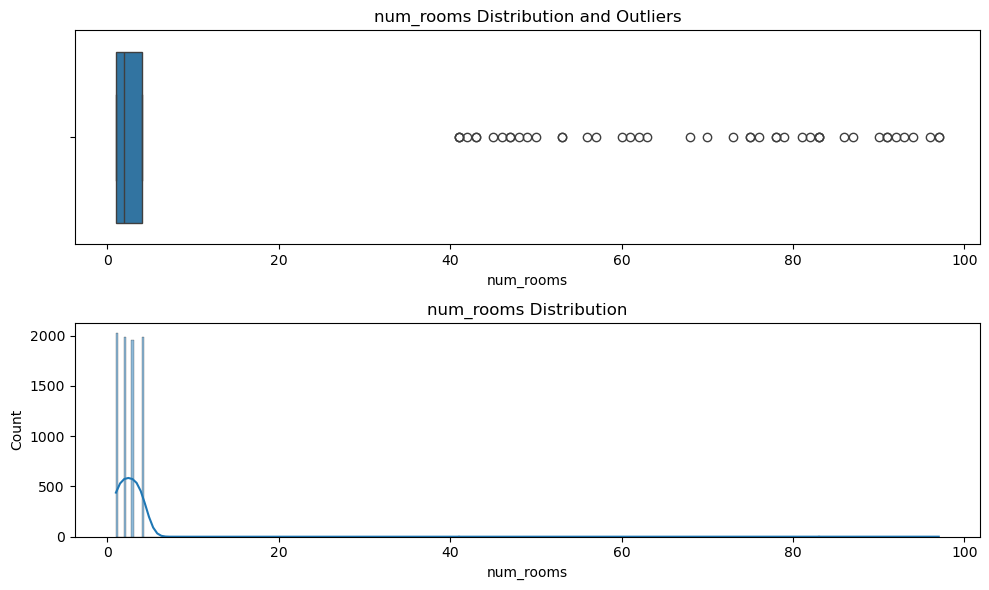

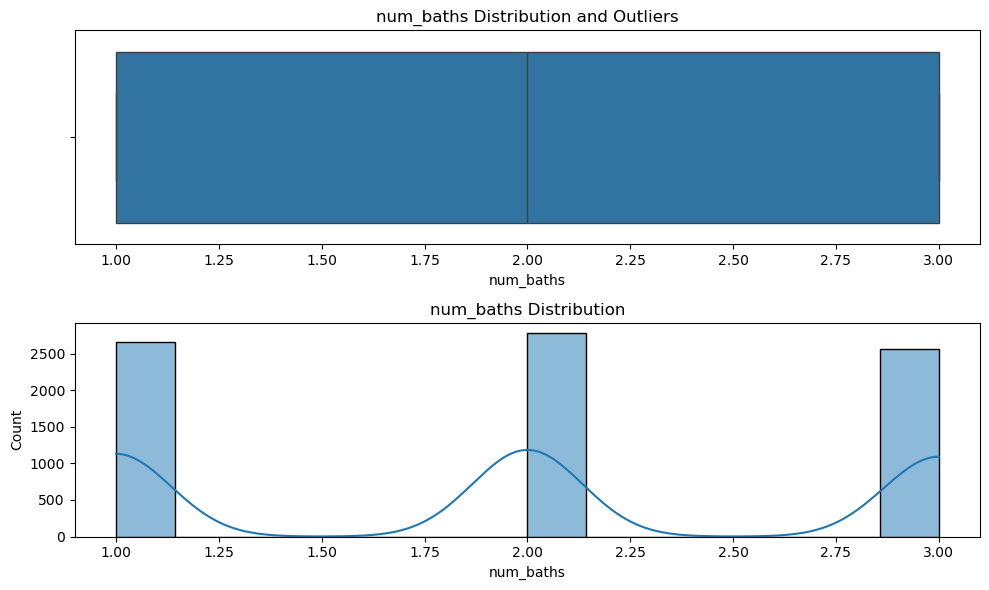

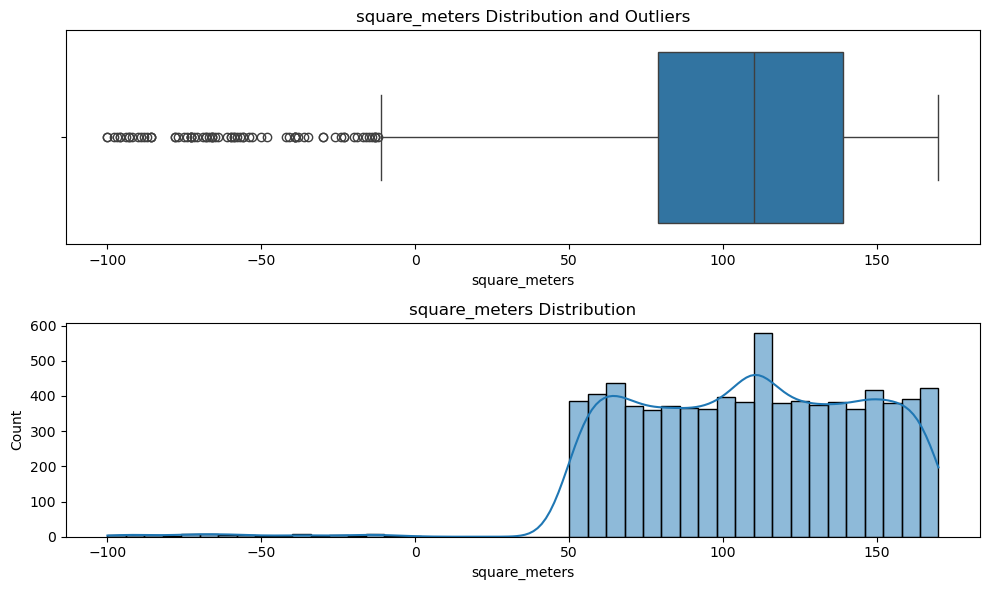

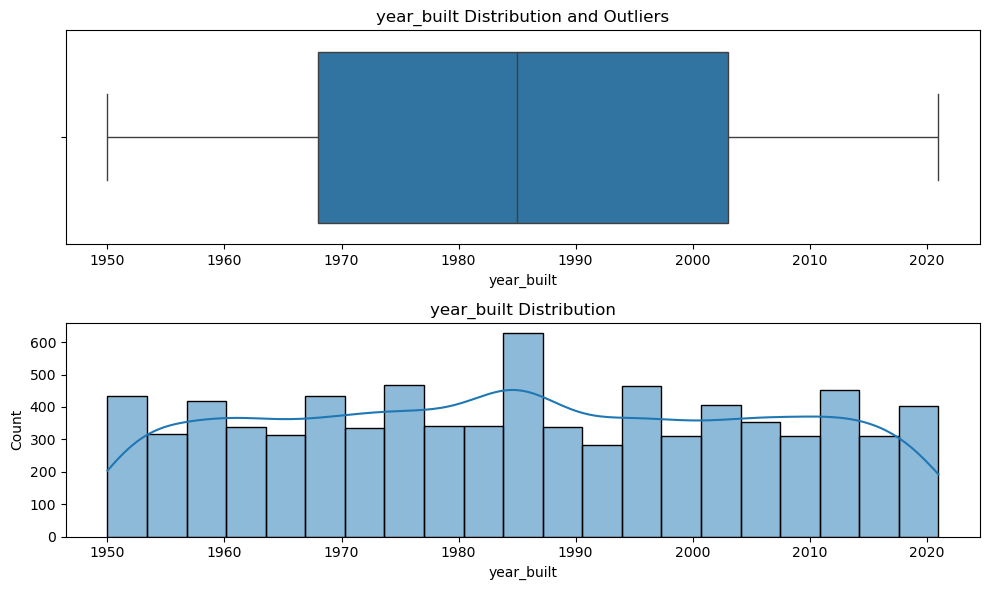

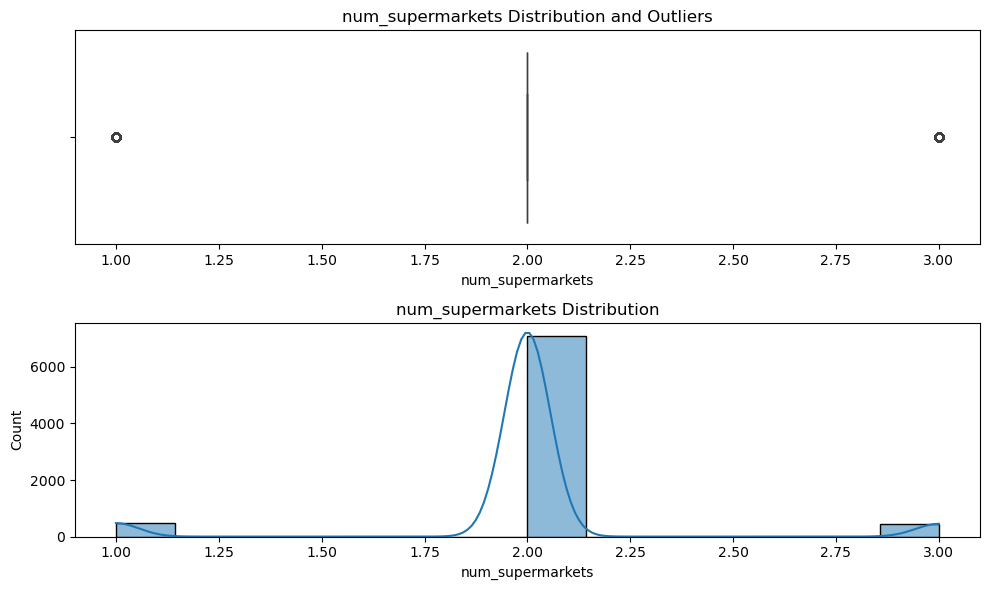

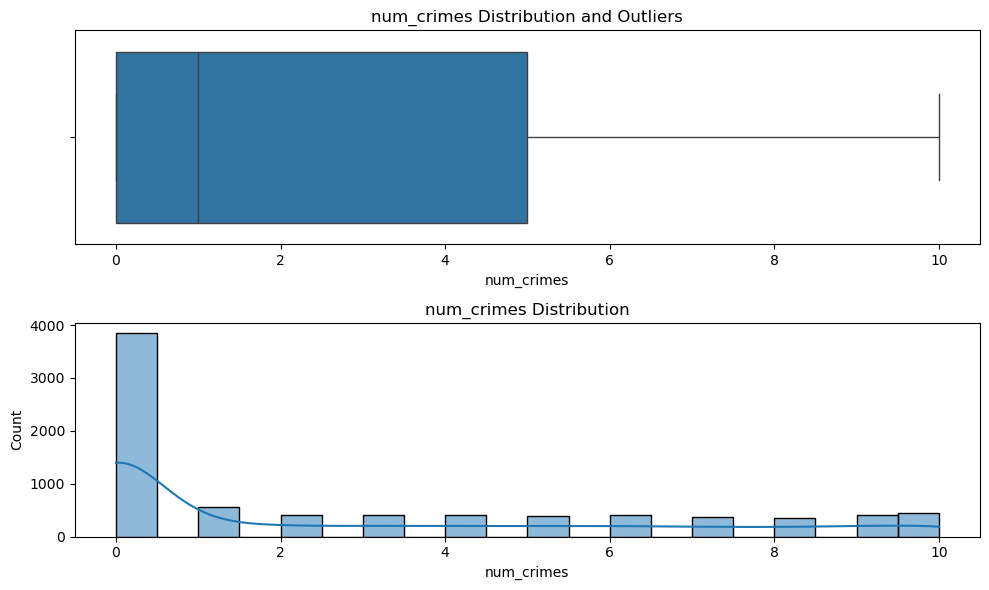

Data Quality Report:
                  num_rooms  num_baths  square_meters  year_built  \
num_rooms               NaN        NaN            NaN         NaN   
num_baths               NaN        NaN            NaN         NaN   
square_meters           NaN        NaN            NaN         NaN   
year_built              NaN        NaN            NaN         NaN   
num_supermarkets        NaN        NaN            NaN         NaN   
num_crimes              NaN        NaN            NaN         NaN   

                  num_supermarkets  num_crimes  
num_rooms                      NaN         NaN  
num_baths                      NaN         NaN  
square_meters                  NaN         NaN  
year_built                     NaN         NaN  
num_supermarkets               NaN         NaN  
num_crimes                     NaN         NaN  


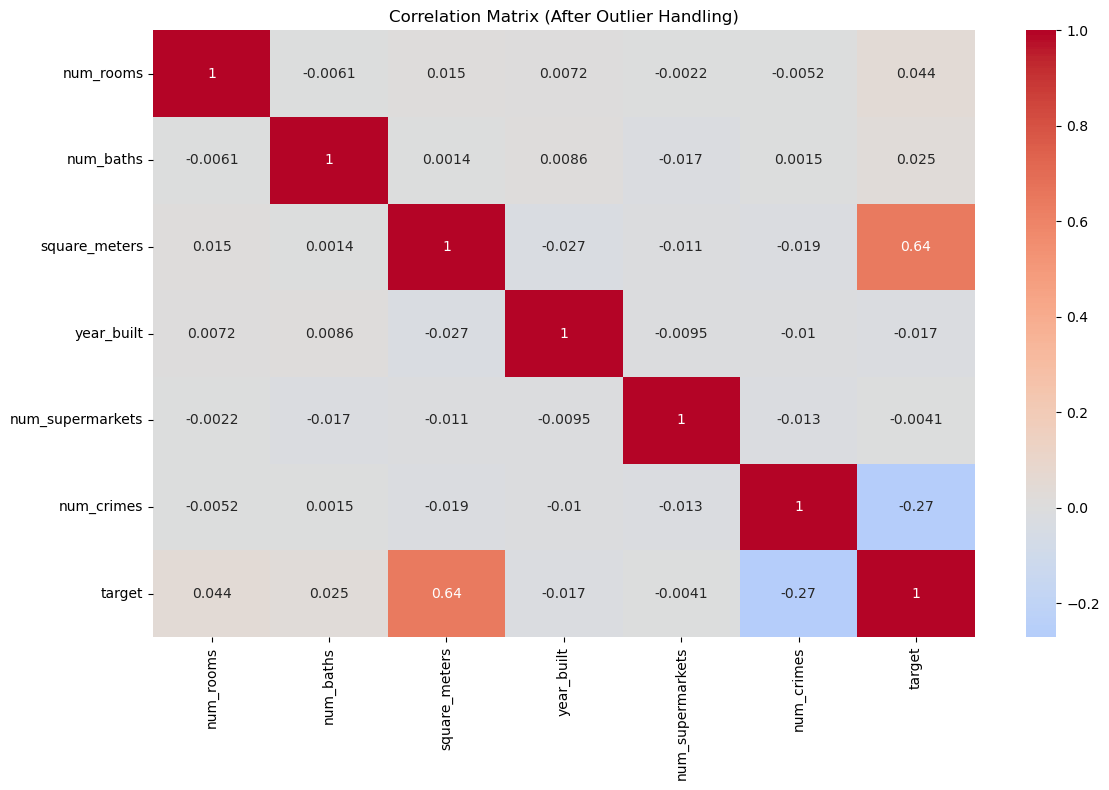

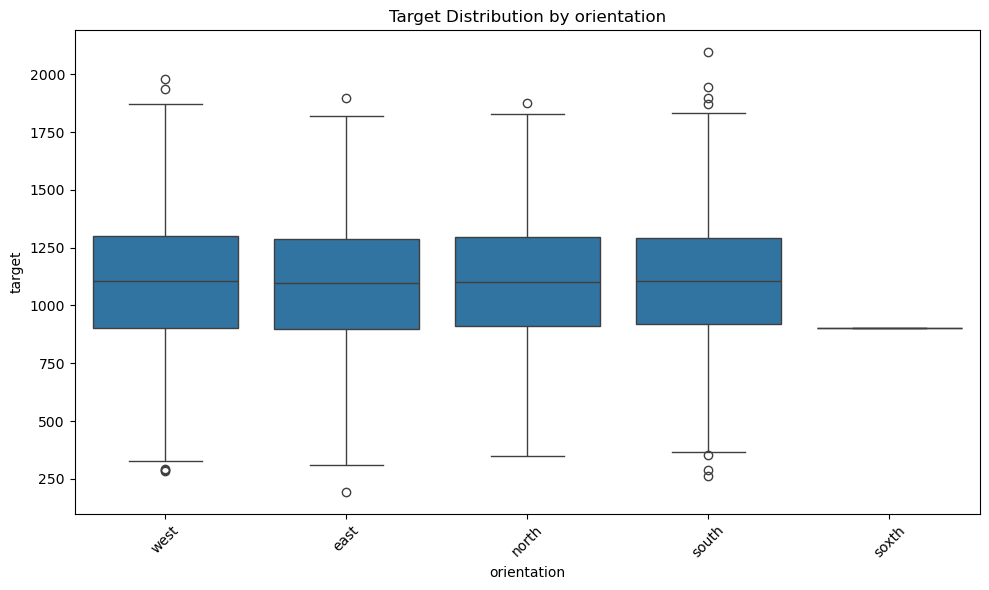

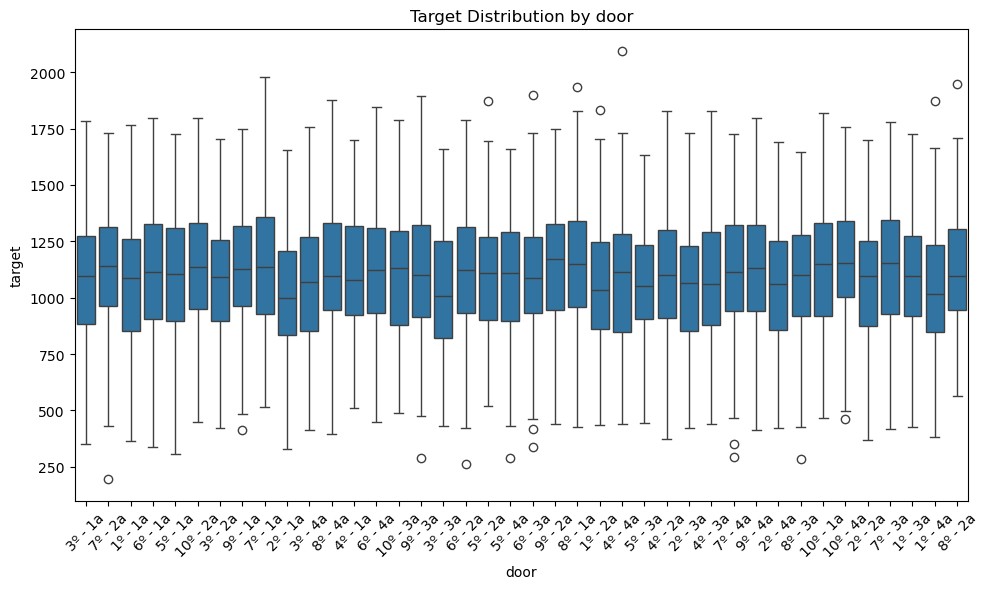

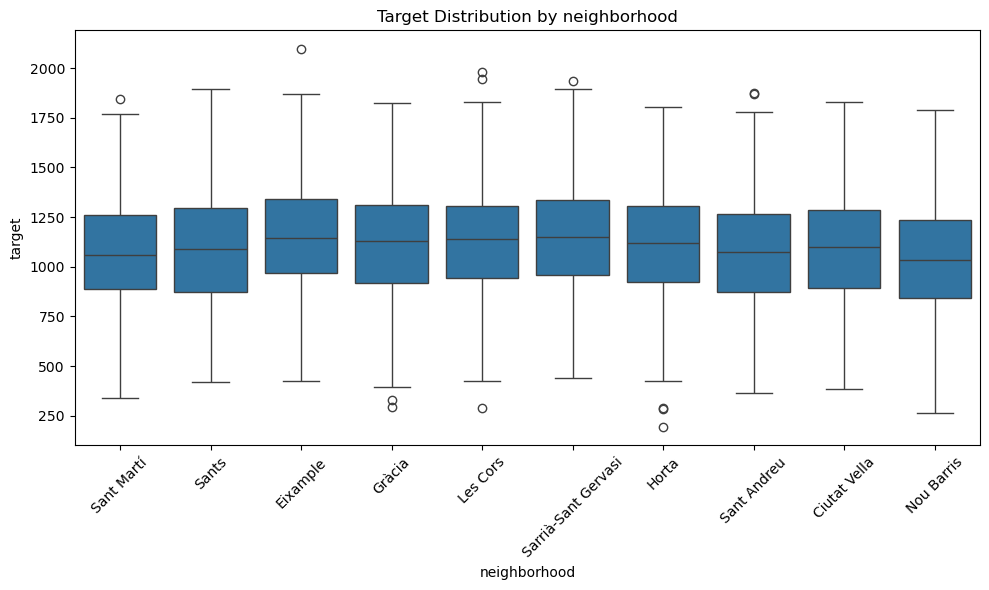

/home/m9o8/miniforge3/envs/std_linux/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:1000: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/m9o8/miniforge3/envs/std_linux/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 139, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/home/m9o8/miniforge3/envs/std_linux/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 371, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/home/m9o8/miniforge3/envs/std_linux/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 89, in _cached_call
    result, _ = _get_response_values(
                ^^^^^^^^^^^^^^^^^^^^^
  File "/home/m9o8/miniforge3/envs/std_linux/lib/python3.12/site-packages/sklearn/utils/_response.py", line 239, in _get_response_values
    y_pred, pos_label = prediction_m

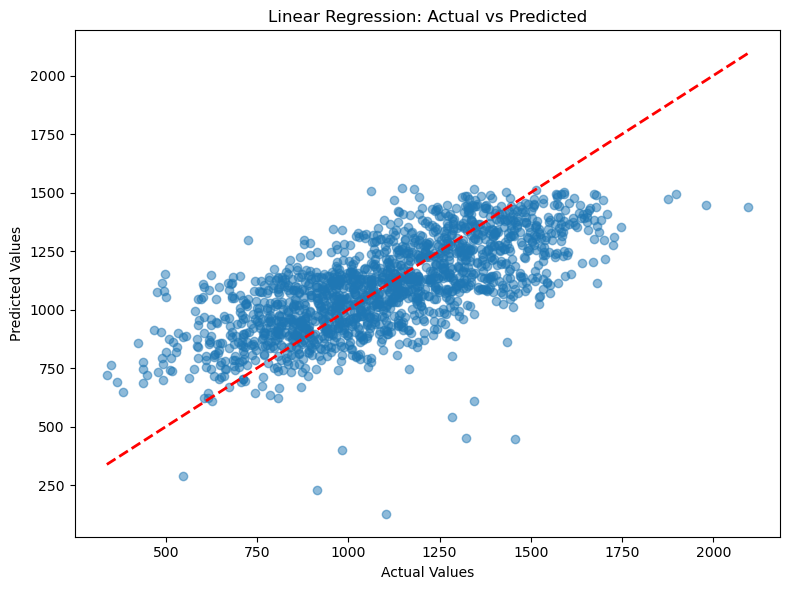

/home/m9o8/miniforge3/envs/std_linux/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:1000: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/m9o8/miniforge3/envs/std_linux/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 139, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/home/m9o8/miniforge3/envs/std_linux/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 371, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/home/m9o8/miniforge3/envs/std_linux/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 89, in _cached_call
    result, _ = _get_response_values(
                ^^^^^^^^^^^^^^^^^^^^^
  File "/home/m9o8/miniforge3/envs/std_linux/lib/python3.12/site-packages/sklearn/utils/_response.py", line 239, in _get_response_values
    y_pred, pos_label = prediction_m

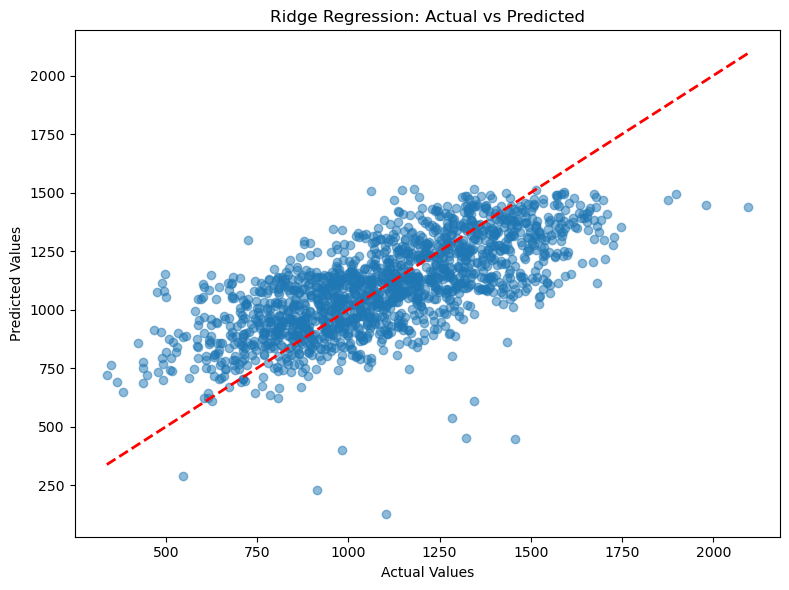

/home/m9o8/miniforge3/envs/std_linux/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:1000: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/m9o8/miniforge3/envs/std_linux/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 139, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/home/m9o8/miniforge3/envs/std_linux/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 371, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/home/m9o8/miniforge3/envs/std_linux/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 89, in _cached_call
    result, _ = _get_response_values(
                ^^^^^^^^^^^^^^^^^^^^^
  File "/home/m9o8/miniforge3/envs/std_linux/lib/python3.12/site-packages/sklearn/utils/_response.py", line 239, in _get_response_values
    y_pred, pos_label = prediction_m

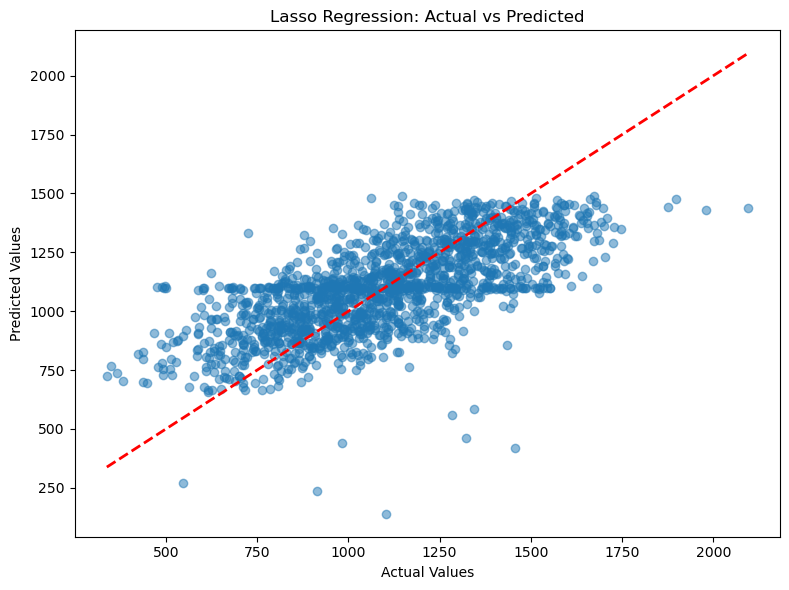

/home/m9o8/miniforge3/envs/std_linux/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:1000: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/m9o8/miniforge3/envs/std_linux/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 139, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/home/m9o8/miniforge3/envs/std_linux/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 371, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/home/m9o8/miniforge3/envs/std_linux/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 89, in _cached_call
    result, _ = _get_response_values(
                ^^^^^^^^^^^^^^^^^^^^^
  File "/home/m9o8/miniforge3/envs/std_linux/lib/python3.12/site-packages/sklearn/utils/_response.py", line 239, in _get_response_values
    y_pred, pos_label = prediction_m

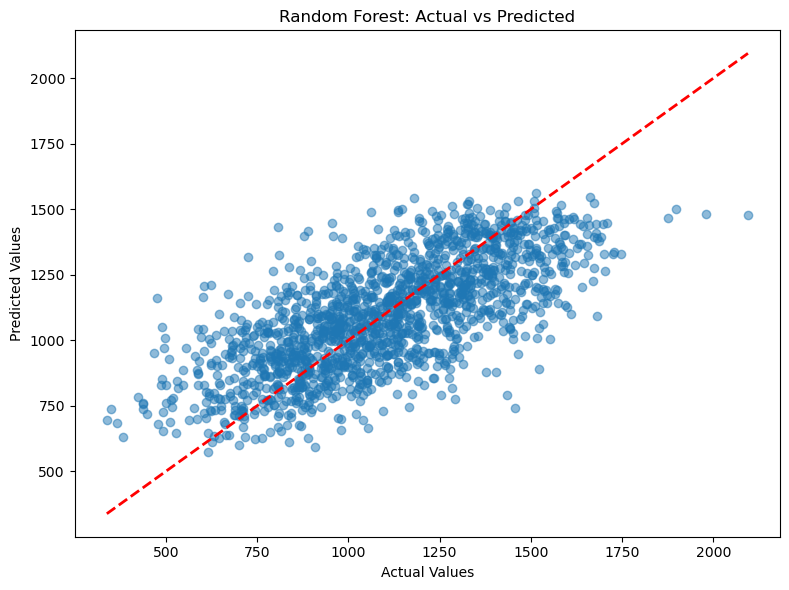


Linear Regression:
R2 Score: 0.4836
RMSE: 197.0015
CV Scores Mean: nan (+/- nan)

Ridge Regression:
R2 Score: 0.4835
RMSE: 197.0198
CV Scores Mean: nan (+/- nan)

Lasso Regression:
R2 Score: 0.4759
RMSE: 198.4541
CV Scores Mean: nan (+/- nan)

Random Forest:
R2 Score: 0.4817
RMSE: 197.3674
CV Scores Mean: nan (+/- nan)


ValueError: could not broadcast input array from shape (8000,13) into shape (8000,)

In [10]:
X,y = load_data('data/train.csv')

# Usage example:

# Initialize the pipeline
pipeline = RegressionPipeline()
pipeline.prepare_preprocessing()

# Analyze data quality including outliers
quality_report = pipeline.analyze_data_quality(X)
print("Data Quality Report:")
print(quality_report)

# Analyze relationships after outlier handling
pipeline.analyze_relationships(X, y)

# Train and evaluate models
results = pipeline.train_and_evaluate_models(X, y)

# Print results
for model_name, metrics in results.items():
    print(f"\n{model_name}:")
    print(f"R2 Score: {metrics['R2 Score']:.4f}")
    print(f"RMSE: {metrics['RMSE']:.4f}")
    print(f"CV Scores Mean: {metrics['CV Scores'].mean():.4f} (+/- {metrics['CV Scores'].std() * 2:.4f})")

# Fit final model and make predictions
final_model = pipeline.fit_predict(X, y, model_type='Ridge')


In [11]:
X,y = load_data('data/test.csv')
predictions = final_model.predict(X)